In [1]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor




In [2]:
# 2. LOAD DATA
# =========================
df = pd.read_csv("/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/diamonds.csv")
df.shape

(53940, 10)

In [3]:
print("Duplicate rows:", df.duplicated().sum())

for col in ['cut','color','clarity']:
    df[col] = df[col].astype(str).str.strip()  # remove spaces
    df[col] = df[col].replace('nan', np.nan)   # fix string 'nan'
print(df.isnull().sum())

Duplicate rows: 146
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [4]:
df = df.drop_duplicates()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  object 
 2   color    53794 non-null  object 
 3   clarity  53794 non-null  object 
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB
None


In [5]:
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].fillna(df[['x', 'y', 'z']].median())


In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

skewness = df[num_cols].skew()
print(skewness)

carat    1.113651
depth   -0.114250
table    0.792227
price    1.618240
x        0.397075
y        2.468675
z        1.589604
dtype: float64


In [7]:
usd_to_inr = 93  # example rate

df['price_inr'] = (df['price'] * usd_to_inr).round(2)
df['price_log'] = np.log1p(df['price_inr'])

print(df['price_log'].skew())

0.1143216322094148


{'carat': np.int64(1873), 'price': np.int64(3523), 'x': np.int64(24), 'y': np.int64(22), 'z': np.int64(29)}


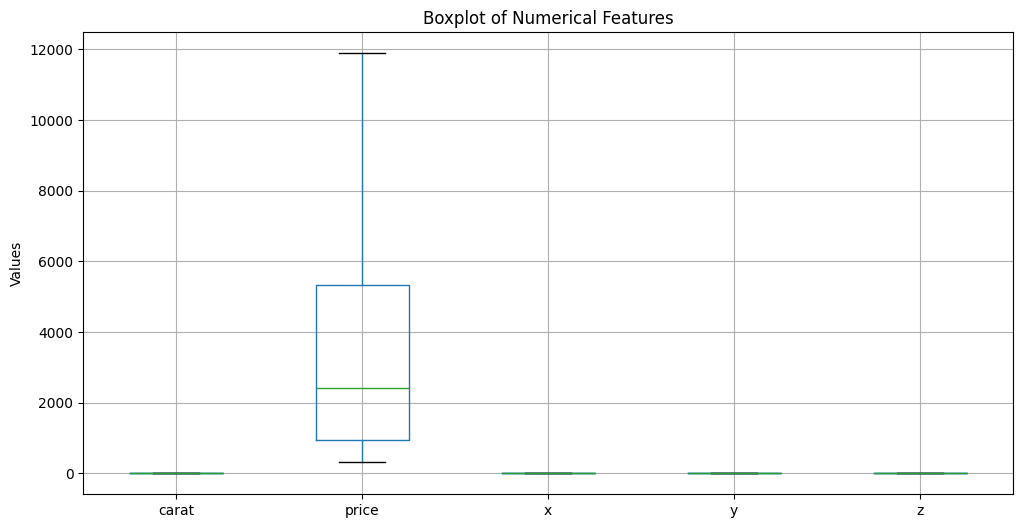

In [8]:
num_cols = ["carat", "price", "x", "y", "z"]
outlier_counts = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    IQR = Q3 - Q1

    outliers = ((df[col] < lower) | (df[col] > upper))

    outlier_counts[col] = outliers.sum()
    
    df[col] = df[col].clip(lower, upper)
print(outlier_counts)   

plt.figure(figsize=(12, 6))
df[num_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.show()

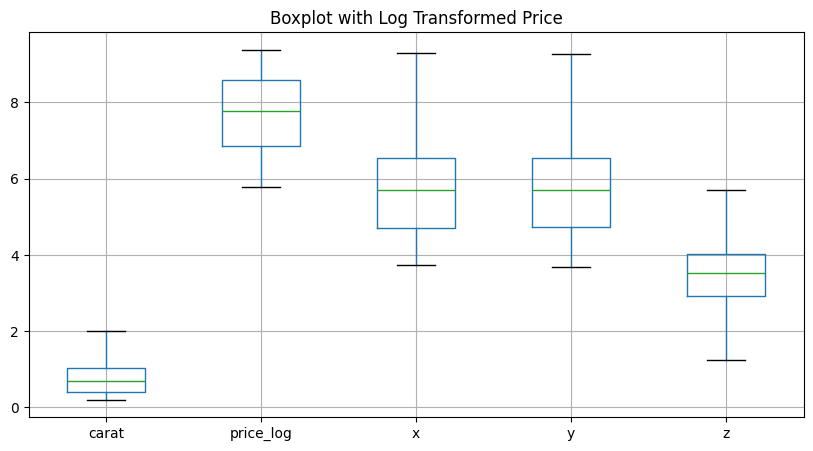

In [9]:
df['price_log'] = np.log1p(df['price'])

df[['carat', 'price_log', 'x', 'y', 'z']].boxplot(figsize=(10,5))
plt.title("Boxplot with Log Transformed Price")
plt.show()

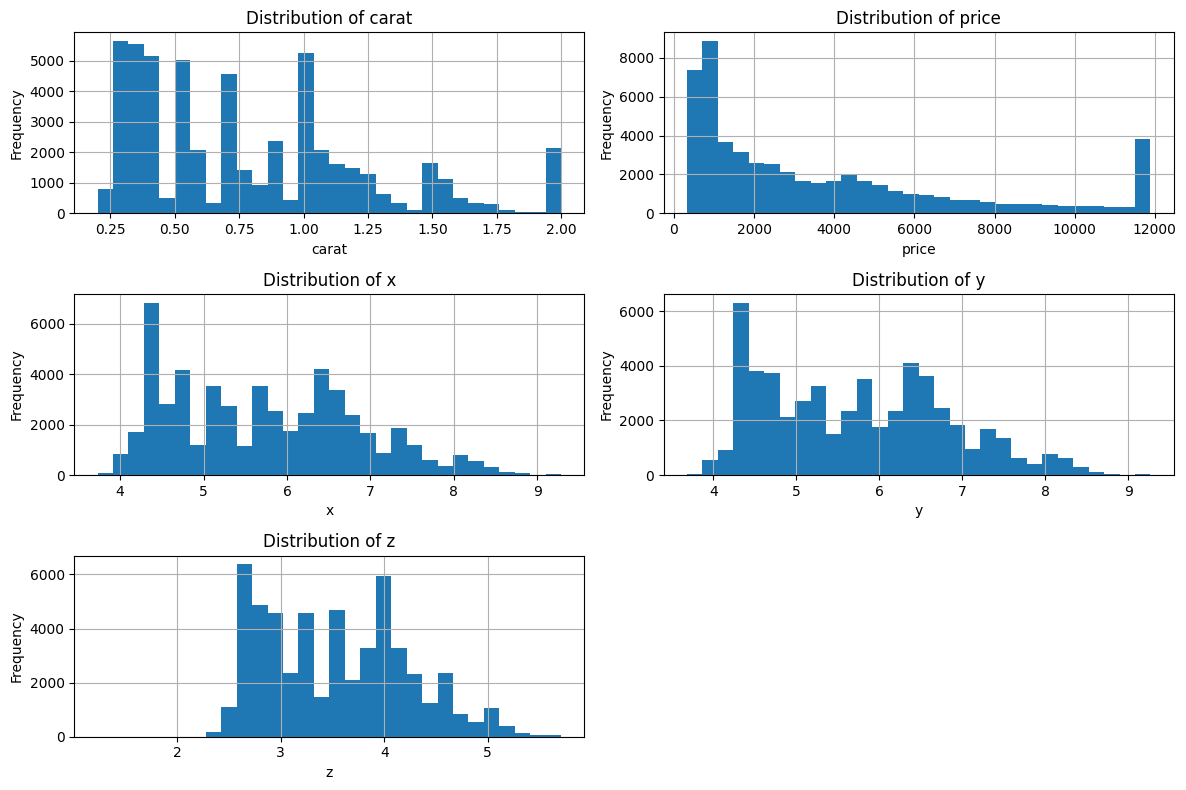

In [10]:
num_cols = ['carat', 'price', 'x', 'y', 'z']

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

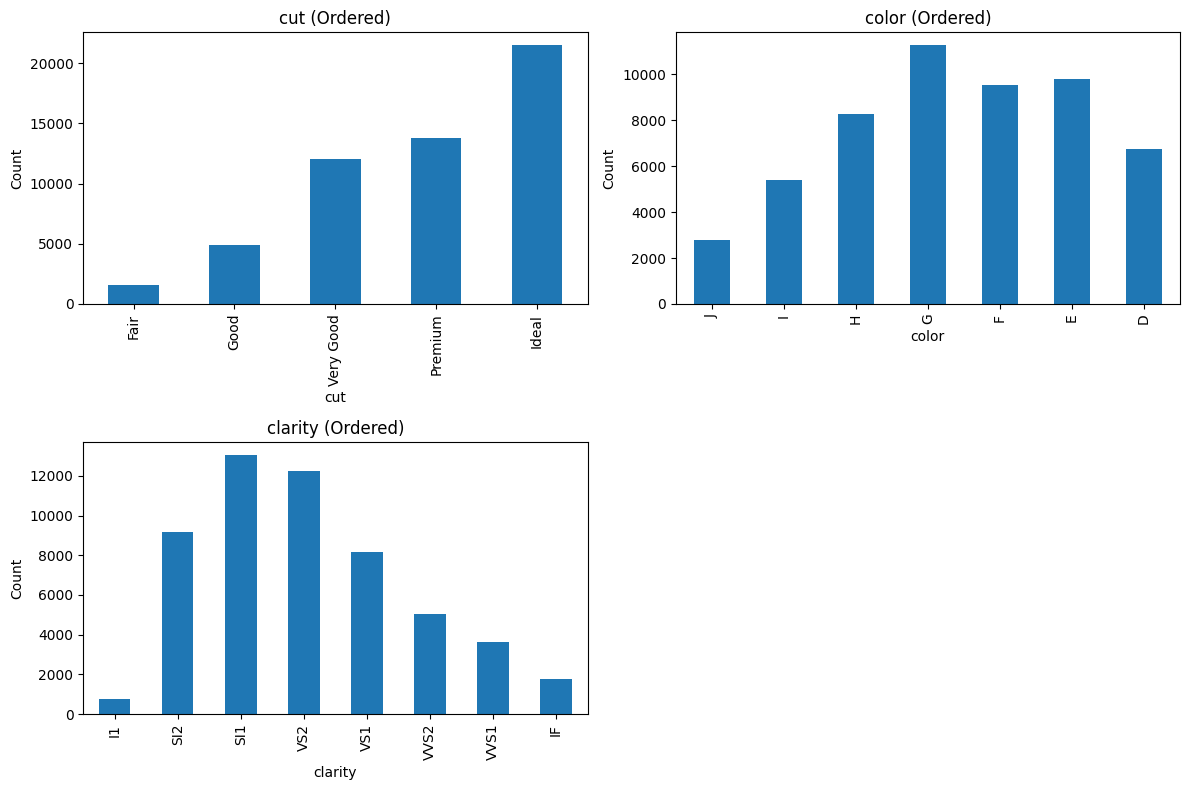

In [11]:
cat_cols = ['cut', 'color', 'clarity']
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

orders = {
    'cut': cut_order,
    'color': color_order,
    'clarity': clarity_order
}

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    df[col].value_counts().reindex(orders[col]).plot(kind='bar')
    plt.title(f"{col} (Ordered)")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

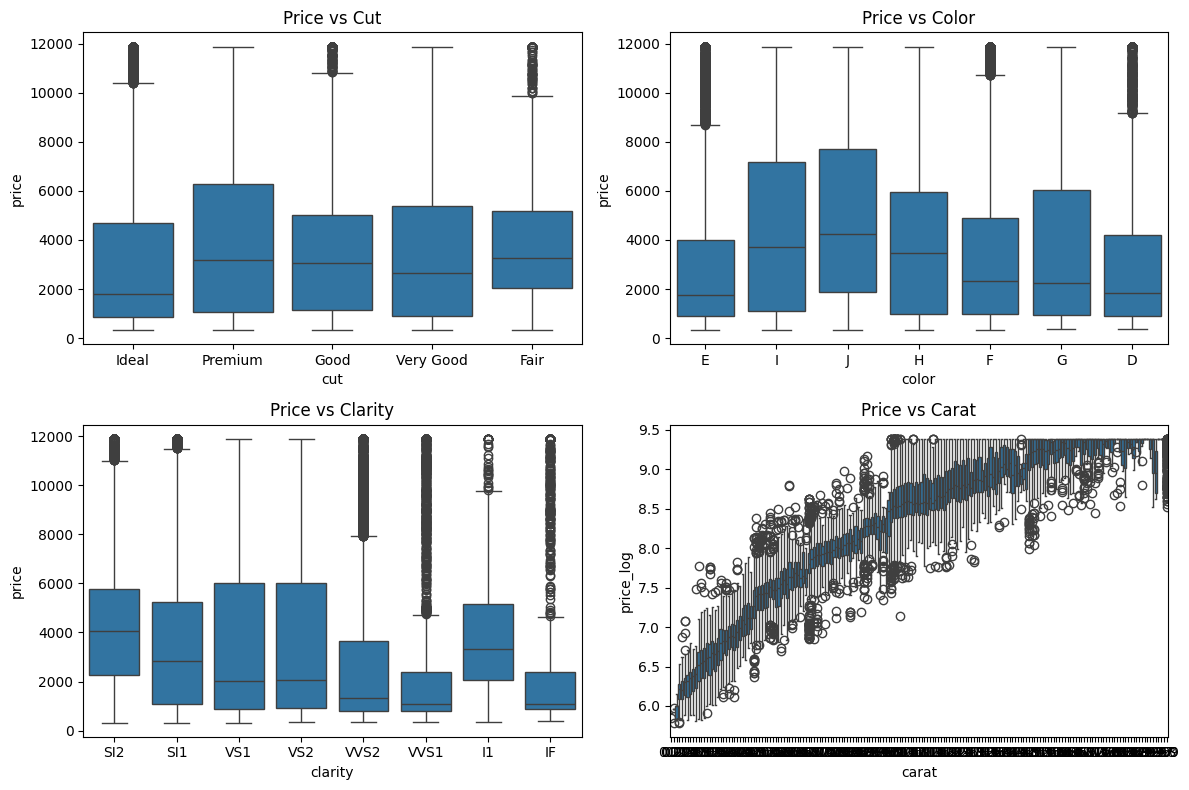

In [12]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(x='cut', y='price', data=df)
plt.title("Price vs Cut")

plt.subplot(2,2,2)
sns.boxplot(x='color', y='price', data=df)
plt.title("Price vs Color")

plt.subplot(2,2,3)
sns.boxplot(x='clarity', y='price', data=df)
plt.title("Price vs Clarity")

plt.subplot(2,2,4)
sns.boxplot(x='carat', y='price_log', data=df)
plt.title("Price vs Carat")
plt.tight_layout()
plt.show()

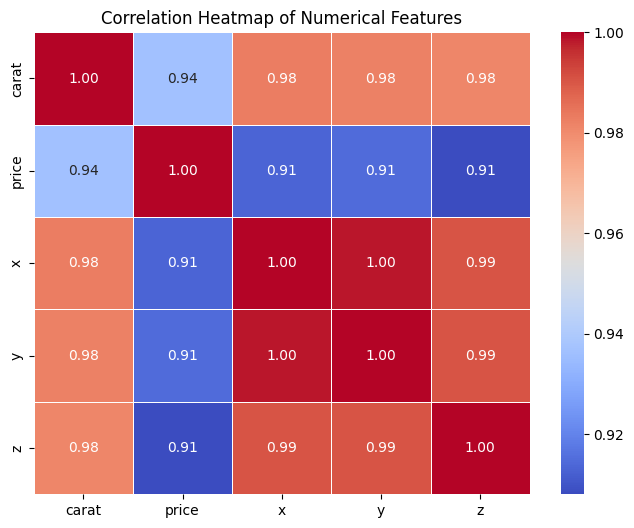

In [13]:
plt.figure(figsize=(8,6))
corr_matrix = df[['carat', 'price', 'x', 'y', 'z']].corr()
sns.heatmap(
    corr_matrix,
    annot=True,        # show values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # color scheme
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

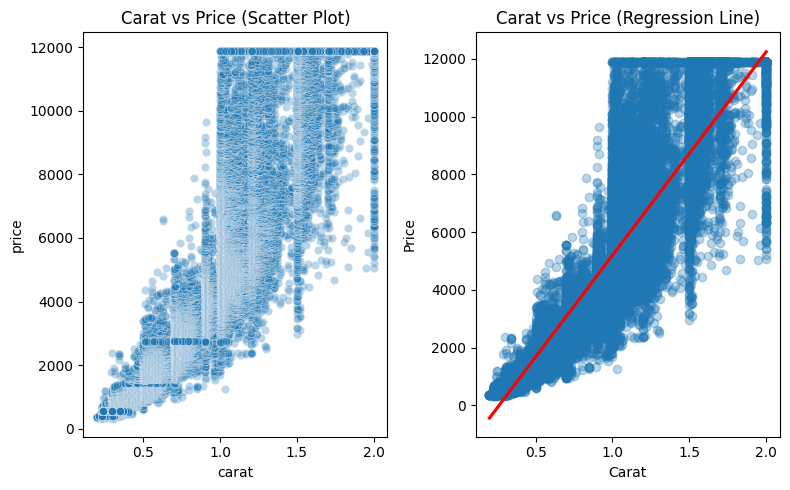

In [14]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title("Carat vs Price (Scatter Plot)")
sns.scatterplot(x='carat', y='price', data=df, alpha=0.3)
plt.subplot(1,2,2)
sns.regplot(
    x='carat',
    y='price',
    data=df,
    scatter_kws={'alpha':0.3},  # reduce clutter
    line_kws={'color':'red'}
)

plt.title("Carat vs Price (Regression Line)")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


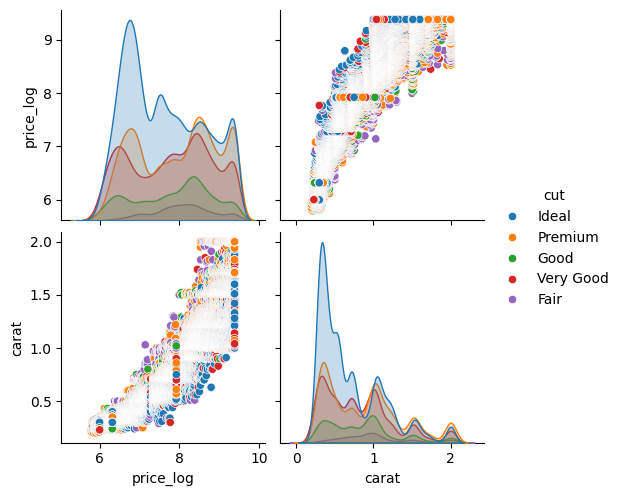

In [15]:
columns= ['price_log','carat']
sns.pairplot(df[columns + ['cut']], hue='cut', diag_kind='kde')
plt.show()

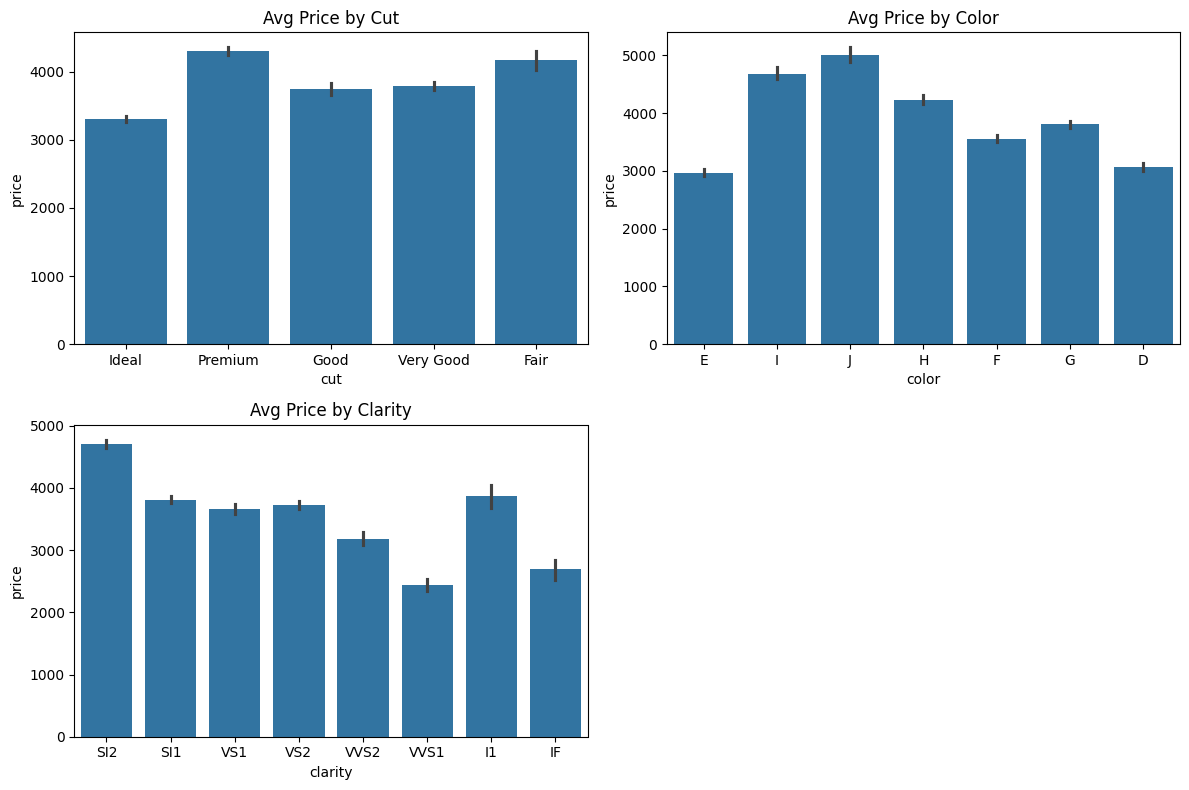

In [16]:
plt.figure(figsize=(12,8))

# Cut
plt.subplot(2,2,1)
sns.barplot(x='cut', y='price', data=df)
plt.title("Avg Price by Cut")

# Color
plt.subplot(2,2,2)
sns.barplot(x='color', y='price', data=df)
plt.title("Avg Price by Color")

# Clarity
plt.subplot(2,2,3)
sns.barplot(x='clarity', y='price', data=df)
plt.title("Avg Price by Clarity")

plt.tight_layout()
plt.show()

In [17]:
# Volume
df['volume'] = df['x'] * df['y'] * df['z']

# Price per Carat
df['price_per_carat'] = df['price'] / df['carat']

# Dimension Ratio
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])



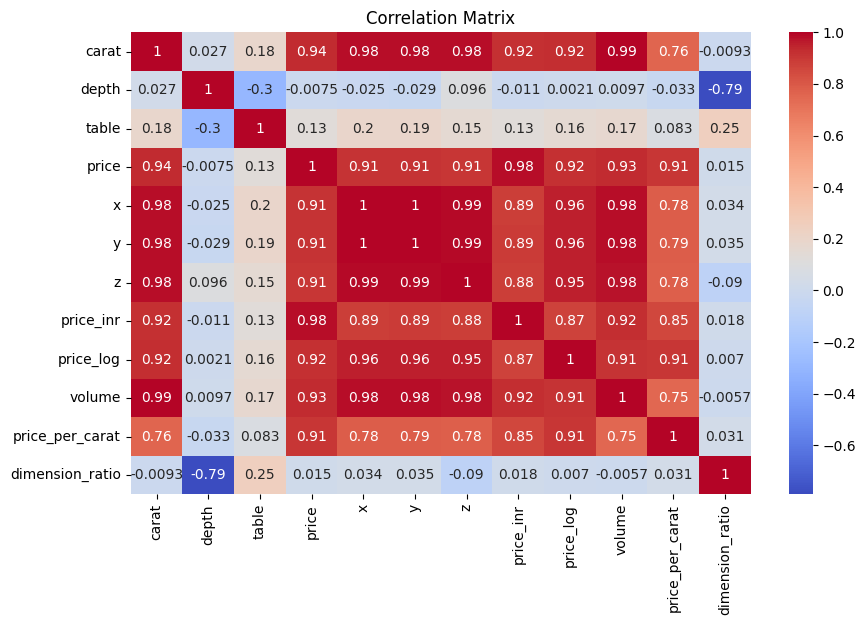

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
# find columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Drop these columns:", to_drop)

# drop them
#df = df.drop(columns=to_drop)
#print(df.shape)

Drop these columns: ['price', 'x', 'y', 'z', 'price_inr', 'price_log', 'volume', 'price_per_carat']


In [20]:
df = df.drop(columns=['x', 'y', 'z', 'price_per_carat', 'dimension_ratio'])
df1=df.copy()
df1

,carat,cut,color,clarity,depth,table,price,price_inr,price_log,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,30318,5.789960,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326.0,30318,5.789960,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327.0,30411,5.793014,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334.0,31062,5.814131,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335.0,31155,5.817111,51.917250
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757.0,256401,7.922261,115.920000
53936,0.72,Good,D,SI1,63.1,55.0,2757.0,256401,7.922261,118.110175
53937,0.70,Very Good,D,SI1,62.8,60.0,2757.0,256401,7.922261,114.449728
53938,0.86,Premium,H,SI2,61.0,58.0,2757.0,256401,7.922261,140.766120


volume     0.872353
carat      0.076205
clarity    0.031157
color      0.014368
depth      0.002635
cut        0.001924
table      0.001357
dtype: float64
(53794, 10)


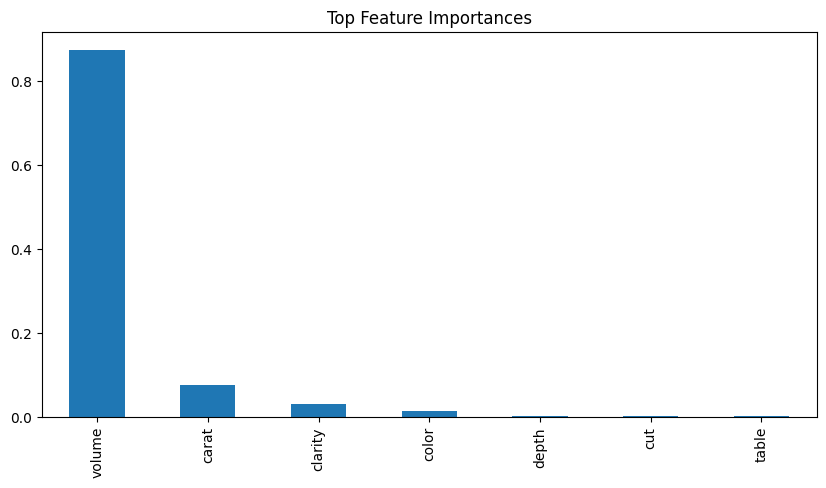

In [21]:
# Ordinal encoding
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8}

df1['cut'] = df['cut'].map(cut_map)
df1['color'] = df['color'].map(color_map)
df1['clarity'] = df['clarity'].map(clarity_map)

X = df1.drop(columns=['price', 'price_inr', 'price_log'])
y = df1['price_log']
# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)

# Sort
importance = importance.sort_values(ascending=False)

# Print top features
print(importance)
print(df.shape)
# Plot
importance.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Feature Importances")
plt.show()

In [22]:
# Split
X = df[['carat','cut','color','clarity','depth','table', 'volume']]
y = df['price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for col in ['cut','color','clarity']:
    X_train[col] = X_train[col].astype(str).str.strip()
    X_test[col] = X_test[col].astype(str).str.strip()

# ✅ Fill categorical safely (NO WARNINGS)
for col in ['cut','color','clarity']:
    if X_train[col].mode().empty:
        X_train[col] = X_train[col].fillna('Unknown')
        X_test[col] = X_test[col].fillna('Unknown')
    else:
        X_train[col] = X_train[col].fillna(X_train[col].mode().iloc[0])
        X_test[col] = X_test[col].fillna(X_test[col].mode().iloc[0])

# 5. ENCODING (IMPORTANT)
# =========================
encoder = OrdinalEncoder(categories=[
    ['Fair','Good','Very Good','Premium','Ideal'],
    ['J','I','H','G','F','E','D'],
    ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
])

X_train[['cut','color','clarity']] = encoder.fit_transform(
    X_train[['cut','color','clarity']]
)

X_test[['cut','color','clarity']] = encoder.transform(
    X_test[['cut','color','clarity']]
)
joblib.dump(encoder, "/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/ordinal_encoder.pkl")



['/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/ordinal_encoder.pkl']

In [23]:
# ✅ Save feature names
features = X_train.columns.tolist()

joblib.dump(features, "/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/features.pkl")

['/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/features.pkl']

In [24]:
# =========================
#  DEFINE MODELS
# =========================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Scale data for ANN ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(),

    # 👇 ADD ANN HERE
    "ANN": MLPRegressor(
        hidden_layer_sizes=(32, 16),
        max_iter=50,
        batch_size=256,
        random_state=42
    )
}

# =========================
#  EVALUATION FUNCTION
# =========================
results = {}

def evaluate_model(name, model):
    
    # 👇 Special handling for ANN
    if name == "ANN":
        model.fit(X_train_scaled, y_train)
        y_pred_log = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)

    # Prevent overflow
    y_pred_log = np.clip(y_pred_log, -10, 10)

    # Convert back from log
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results[name] = [mae, mse, rmse, r2]

# =========================
#  TRAIN ALL MODELS
# =========================
for name, model in models.items():
    evaluate_model(name, model)

# =========================
#  COMPARE MODELS
# =========================
results_df = pd.DataFrame(results, index=['MAE','MSE','RMSE','R2']).T
results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df)

                           MAE           MSE         RMSE        R2
XGBoost             214.118775  1.347284e+05   367.053617  0.988185
Random Forest       213.217730  1.519412e+05   389.796370  0.986675
Decision Tree       271.948846  2.624932e+05   512.340931  0.976980
KNN                 296.233511  2.889678e+05   537.557260  0.974658
ANN                 323.966385  3.018665e+05   549.423791  0.973527
Linear Regression  1133.662908  5.204474e+06  2281.331557  0.543581


In [31]:

# =========================
# 7. MODEL (TUNED XGBOOST)
# =========================
best_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# =========================
# 8. TRAIN
# =========================
best_model.fit(X_train, y_train)

# =========================
# 9. PREDICT
# =========================
y_pred_log = best_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# =========================
# 10. EVALUATE
# =========================
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MAPE:", mape)
print("Accuracy:", (1 - mape) * 100, "%")

MAPE: 0.06932888842328318
Accuracy: 93.06711115767168 %


In [32]:
# =========================
#  SAVE BEST MODEL
# =========================
joblib.dump(best_model, "/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/best_model.pkl")

print("✅ Best model saved successfully")

✅ Best model saved successfully


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Copy dataset
df_cluster = df.copy()

# Encode categorical variables (same mapping as before)
cut_map = {"Fair":0, "Good":1, "Very Good":2, "Premium":3, "Ideal":4}
color_map = {"D":0, "E":1, "F":2, "G":3, "H":4, "I":5, "J":6}
clarity_map = {"I1":0, "SI2":1, "SI1":2, "VS2":3, "VS1":4, "VVS2":5, "VVS1":6, "IF":7}

df_cluster["cut"] = df_cluster["cut"].map(cut_map)
df_cluster["color"] = df_cluster["color"].map(color_map)
df_cluster["clarity"] = df_cluster["clarity"].map(clarity_map)

# Select features
features = ['carat','cut','color','clarity','depth','table']
X = df_cluster[features]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

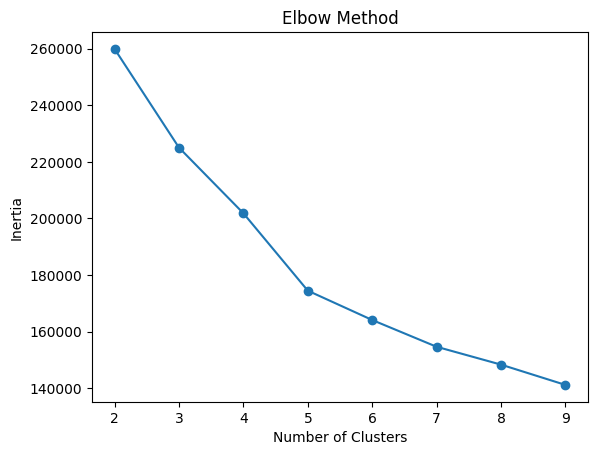

In [28]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [29]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.195
K=3, Silhouette Score=0.197
K=4, Silhouette Score=0.163


KeyboardInterrupt: 

In [ ]:
# =========================
# KMEANS (k=4)
# =========================
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)
# =========================
# PCA (2D for visualization)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_cluster["pca1"] = X_pca[:, 0]
df_cluster["pca2"] = X_pca[:, 1]

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="pca1",
    y="pca2",
    hue="cluster",
    data=df_cluster,
    palette="viridis"
)

plt.title("KMeans Clusters (k=4)")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.2, min_samples=10)
df_cluster["cluster"] = db.fit_predict(X_scaled)

print(df_cluster["cluster"].value_counts())
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="pca1",
    y="pca2",
    hue="cluster",
    data=df_cluster[df_cluster["cluster"] != -1],  # remove noise
    palette="tab10"
)

plt.title("DBSCAN Clusters (clean)")
plt.show()

In [ ]:
# =========================
# CLUSTER SUMMARY
# =========================
cluster_summary = df_cluster.groupby("cluster").agg({
    "price": "mean",
    "carat": "mean"
}).round(2)

print(cluster_summary)

In [ ]:
cluster_names = {
    0: "Premium Heavy Diamonds",
    1: "Affordable Small Diamonds",
    2: "Mid-range Balanced Diamonds",
    3: "Budget Medium Diamonds"
}

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)
df_cluster.groupby("cluster_name")[["price", "carat"]].mean()

In [ ]:
joblib.dump(kmeans, "/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/kmeans_model.pkl")
joblib.dump(scaler, "/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/cluster_scaler.pkl")

In [ ]:
joblib.dump(features, "/Users/Pooja/Documents/capstone_projects/projects/Diamond dynamics/cluster_features.pkl")